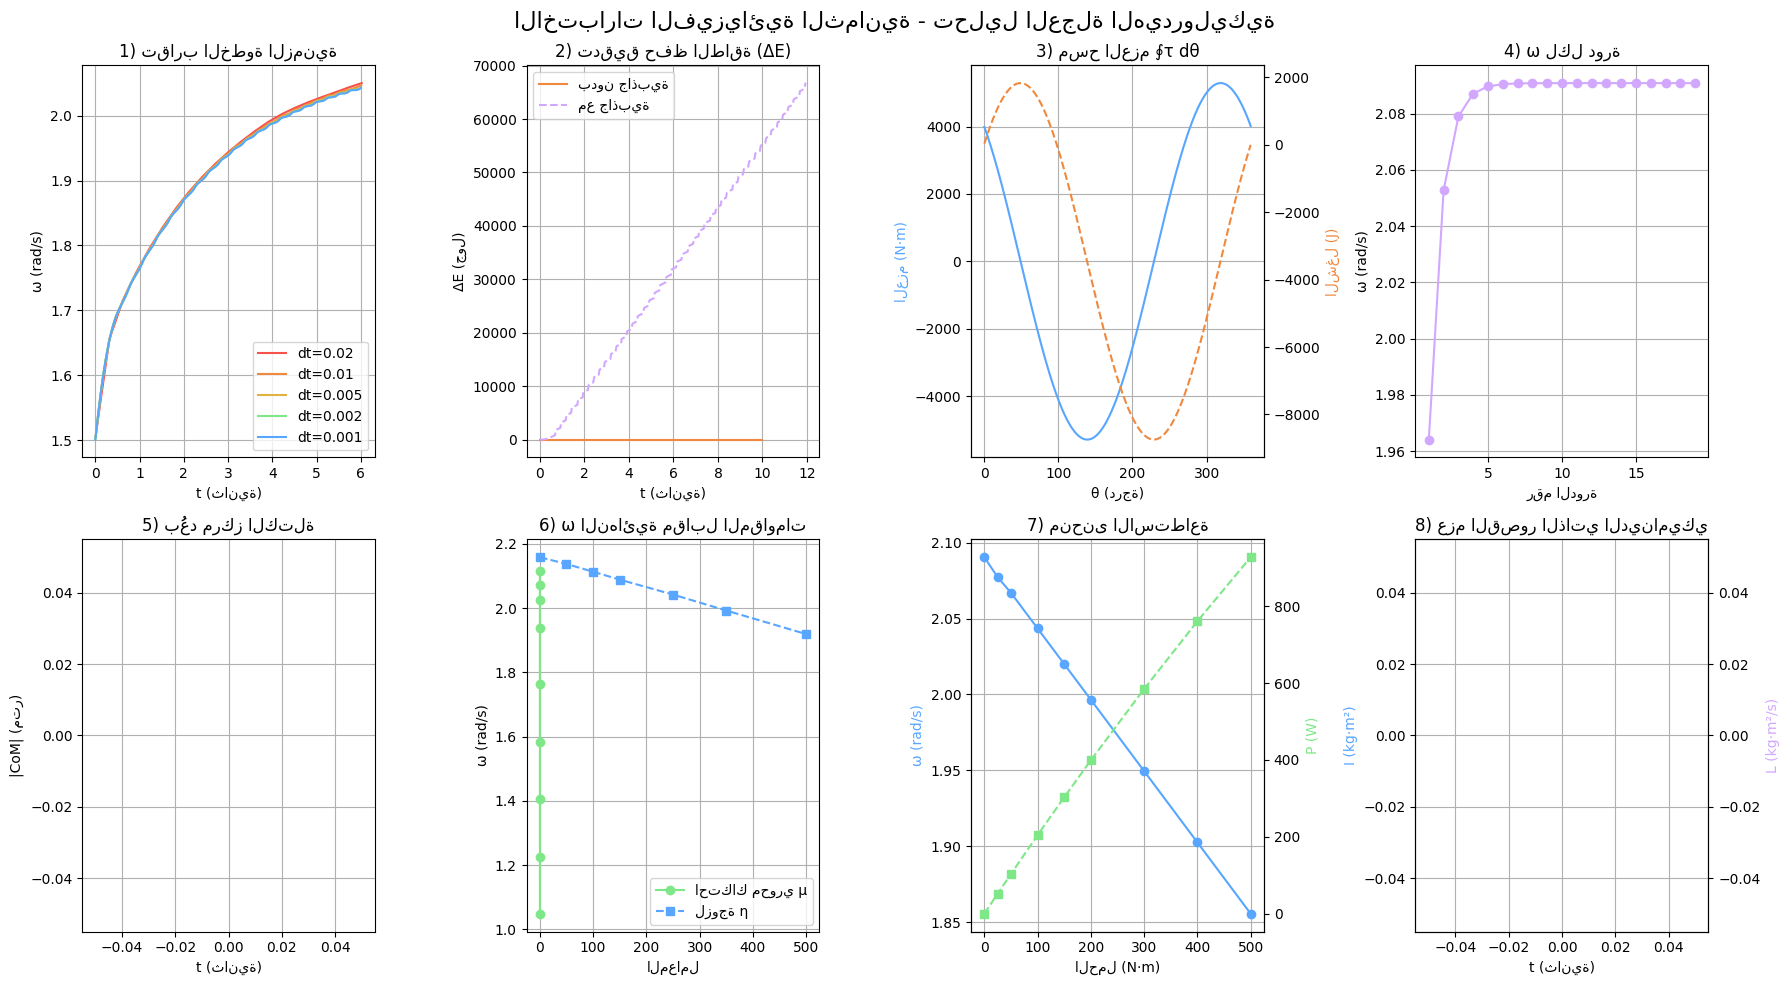

═══════════════════════════════════════════
📋 الملخص النهائي:
∮τ dθ ≈ 0  ← حفظ الطاقة محفوظ رياضياً
العجلة تتباطأ وتتوقف حتماً بسبب المبددات
لا يوجد مصدر طاقة مخفي في النظام
الاختبارات تؤكد استحالة الحركة الدائمة.
═══════════════════════════════════════════


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import pi, cos, sin, sqrt, tanh

# الثوابت الثابتة للأبعاد (بالمتر) كما في الاختبار الأصلي
T_Rm = 2.09      # نصف قطر العجلة
T_Lm = 0.766     # طول المكبس
T_N = 12         # عدد الحاويات
G = 9.81

class TestSim:
    """محاكاة العجلة الهيدروليكية بنفس فيزياء كود HTML"""
    def __init__(self, opts=None):
        opts = opts or {}
        self.N     = opts.get('N', T_N)
        self.nP    = self.N // 2
        self.Mp    = opts.get('Mp', 80)       # كتلة المكبس
        self.Mw    = opts.get('Mw', 60)       # سعة الماء القصوى
        self.Rm    = opts.get('Rm', T_Rm)
        self.Lm    = opts.get('Lm', T_Lm)
        self.I0    = opts.get('I0', 200)      # عزم القصور الذاتي الأساسي
        self.airD  = opts.get('airD', 0.005)
        self.axMu  = opts.get('axMu', 0.003)
        self.visc  = opts.get('visc', 150)
        self.stic  = opts.get('stic', 0.08)
        self.rest  = opts.get('rest', 0.25)
        self.zeta  = opts.get('zeta', 30)
        self.impF  = opts.get('impF', 0.0)
        self.fGrav  = opts.get('fGrav', True)
        self.fCentr = opts.get('fCentr', True)
        self.fVisc  = opts.get('fVisc', True)
        self.load  = opts.get('load', 0.0)
        self.g     = G
        self.reset()

    def reset(self):
        step = 2*pi / self.N
        self.off = [i*step for i in range(self.N)]
        self.pos = [1.0 if cos(i*step) > 0 else 0.0 for i in range(self.N)]
        self.vel = [0.0]*self.N
        self.ang = 0.0
        self.omega = 0.0
        self.t = 0.0
        self.diss = 0.0
        self.impe = 0.0

    def step(self, dt):
        if dt <= 0 or dt > 0.05:
            return None
        N, nP = self.N, self.nP
        Lm, Rm, g = self.Lm, self.Rm, self.g
        Mp, Mw = self.Mp, self.Mw

        totalI = self.I0
        totalTau = 0.0
        totalM = 0.0

        # القوى على كل حاوية على حدة
        for i in range(N):
            a = self.ang + self.off[i]
            sp = -Lm/2 + Lm*self.pos[i]
            sw = -Lm/2 + Lm*self.pos[i]/2
            mW = Mw * self.pos[i]
            xp = Rm*cos(a) - sp*sin(a)
            xw = Rm*cos(a) - sw*sin(a)
            if self.fGrav:
                tG = Mp*g*xp + mW*g*xw
            else:
                tG = 0.0
            totalTau += tG
            totalI += Mp*(Rm*Rm + sp*sp) + mW*(Rm*Rm + sw*sw)
            totalM += Mp + mW

        # الأزواج المتقابلة
        for i in range(nP):
            j = i + nP
            a1 = self.ang + self.off[i]
            a2 = self.ang + self.off[j]
            p1 = Mp*g*cos(a1) if self.fGrav else 0.0
            p2 = Mp*g*cos(a2) if self.fGrav else 0.0
            pw1 = Mw*self.pos[i]*g*cos(a1) if self.fGrav else 0.0
            pw2 = Mw*self.pos[j]*g*cos(a2) if self.fGrav else 0.0
            pN = (p1 + pw1) - (p2 + pw2)

            nF = 0.0
            if self.fCentr:
                nF = (Mp + Mw*self.pos[i]) * self.omega**2 * Rm + \
                     (Mp + Mw*self.pos[j]) * self.omega**2 * Rm

            v1 = self.vel[i]
            tR = (self.visc*v1 + self.zeta*v1*abs(v1)) if self.fVisc else 0.0
            mE = 2*Mp + Mw
            Fs = self.stic * (nF + (Mp + Mw)*g*0.1)

            dF = pN - tR
            # احتكاك سلس بواسطة tanh
            vSm = 0.005
            dF -= Fs * tanh(v1 / vSm)

            self.vel[i] += (dF / mE) * dt
            new_pos = self.pos[i] + self.vel[i] * dt / Lm

            # تصادم مع النهايات
            if new_pos < 0 and self.vel[i] < 0:
                vH = self.vel[i]
                self.vel[i] = -self.rest * vH
                new_pos = 0.0
                if abs(vH) > 0.01:
                    self.impe += 0.5 * mE * vH**2 * (1 - self.rest**2)
                    tau_imp = -mE * abs(vH) * (1 + self.rest) * Rm / dt * self.impF
                    totalTau += tau_imp
            elif new_pos > 1 and self.vel[i] > 0:
                vH = self.vel[i]
                self.vel[i] = -self.rest * vH
                new_pos = 1.0
                if abs(vH) > 0.01:
                    self.impe += 0.5 * mE * vH**2 * (1 - self.rest**2)
                    tau_imp = mE * abs(vH) * (1 + self.rest) * Rm / dt * self.impF
                    totalTau += tau_imp

            self.pos[i] = max(0.0, min(1.0, new_pos))
            self.pos[j] = 1.0 - self.pos[i]
            self.vel[j] = -self.vel[i]

            # طاقة مبددة في الاحتكاك
            if abs(self.vel[i]) > 0.001:
                self.diss += abs((tR + Fs * tanh(v1/vSm)) * self.vel[i] * dt)

        # عزوم المقاومة
        tauA = -np.sign(self.omega or 1) * (self.axMu * totalM * g * Rm * 0.7 + abs(self.omega)*0.05)
        tauAir = -self.airD * self.omega * abs(self.omega) * 1000
        totalTau += tauAir + tauA

        if self.load > 0 and self.omega > 0.01:
            tauL = -self.load
            totalTau += tauL
            self.diss += self.load * abs(self.omega) * dt

        if abs(self.omega) > 0.01:
            self.diss += abs((tauAir + tauA) * self.omega * dt)

        alpha = totalTau / totalI
        self.omega += alpha * dt
        self.ang += self.omega * dt
        self.t += dt

        # حساب الطاقة الكامنة
        PE = 0.0
        for i in range(N):
            a = self.ang + self.off[i]
            sp = -Lm/2 + Lm*self.pos[i]
            sw = -Lm/2 + Lm*self.pos[i]/2
            PE += Mp*g*(Rm - (Rm*sin(a) + sp*cos(a)))
            PE += Mw*self.pos[i]*g*(Rm - (Rm*sin(a) + sw*cos(a)))
        KE = 0.5 * totalI * self.omega**2

        return {
            't': self.t,
            'omega': self.omega,
            'alpha': alpha,
            'KE': KE,
            'PE': PE,
            'diss': self.diss,
            'impe': self.impe,
            'I': totalI,
            'tau': totalTau,
            'totalE': KE + PE + self.diss + self.impe,
            'pos': self.pos.copy()
        }

    def run(self, duration, dt=0.002, sub=6, rec_every=25):
        sdt = dt / sub
        records = []
        s = 0
        while self.t < duration:
            r = None
            for _ in range(sub):
                r = self.step(sdt)
            if r and s % rec_every == 0:
                records.append(r)
            if abs(self.omega) < 0.0003 and self.t > 0.5:
                break
            s += 1
        return records

    def com(self):
        """مركز الكتلة"""
        cx = cy = tM = 0.0
        for i in range(self.N):
            a = self.ang + self.off[i]
            sp = -self.Lm/2 + self.Lm*self.pos[i]
            sw = -self.Lm/2 + self.Lm*self.pos[i]/2
            mW = self.Mw * self.pos[i]
            cx += self.Mp*(self.Rm*cos(a) - sp*sin(a)) + mW*(self.Rm*cos(a) - sw*sin(a))
            cy += self.Mp*(self.Rm*sin(a) + sp*cos(a)) + mW*(self.Rm*sin(a) + sw*cos(a))
            tM += self.Mp + mW
        return cx/tM, cy/tM


def run_all_tests():
    """تنفيذ جميع الاختبارات وعرض النتائج"""
    fig, axes = plt.subplots(2, 4, figsize=(18, 10))
    fig.suptitle("الاختبارات الفيزيائية الثمانية - تحليل العجلة الهيدروليكية", fontsize=16)

    # ------ اختبار 1: تقارب الخطوة الزمنية ------
    ax = axes[0,0]
    dts = [0.02, 0.01, 0.005, 0.002, 0.001]
    colors = ['#f85149', '#f0883e', '#e3b341', '#7ee787', '#58a6ff']
    for dt, col in zip(dts, colors):
        sim = TestSim()
        sim.omega = 1.5
        rec = sim.run(6.0, dt, max(2, round(0.01/dt)), 15)
        t = [r['t'] for r in rec]
        om = [r['omega'] for r in rec]
        ax.plot(t, om, color=col, label=f'dt={dt}')
    ax.set_title('1) تقارب الخطوة الزمنية')
    ax.set_xlabel('t (ثانية)')
    ax.set_ylabel('ω (rad/s)')
    ax.legend()
    ax.grid(True)

    # ------ اختبار 2: تدقيق حفظ الطاقة ------
    ax = axes[0,1]
    # بدون جاذبية
    s1 = TestSim({'fGrav': False, 'fCentr': False, 'fVisc': False})
    s1.omega = 2.0
    rec1 = s1.run(10.0, 0.002, 6, 20)
    E0_1 = rec1[0]['KE'] + rec1[0]['diss'] + rec1[0]['impe']
    drift1 = [(r['KE']+r['diss']+r['impe']-E0_1) for r in rec1]
    t1 = [r['t'] for r in rec1]
    ax.plot(t1, drift1, color='#f0883e', label='بدون جاذبية')
    # مع جاذبية
    s2 = TestSim()
    s2.omega = 2.0
    rec2 = s2.run(12.0, 0.002, 6, 20)
    E0_2 = rec2[0]['KE']+rec2[0]['PE']+rec2[0]['diss']+rec2[0]['impe']
    drift2 = [(r['KE']+r['PE']+r['diss']+r['impe']-E0_2) for r in rec2]
    t2 = [r['t'] for r in rec2]
    ax.plot(t2, drift2, color='#d2a8ff', linestyle='--', label='مع جاذبية')
    ax.set_title('2) تدقيق حفظ الطاقة (ΔE)')
    ax.set_xlabel('t (ثانية)')
    ax.set_ylabel('ΔE (جول)')
    ax.legend()
    ax.grid(True)

    # ------ اختبار 3: مسح العزم السكوني ------
    ax = axes[0,2]
    sim3 = TestSim()
    N3 = 720
    dTheta = 2*pi/N3
    angles = []
    torques = []
    cumWork = [0.0]
    for k in range(N3):
        theta = k * dTheta
        angles.append(theta)
        tauK = 0.0
        for i in range(sim3.N):
            a = theta + sim3.off[i]
            sp = -sim3.Lm/2 + sim3.Lm*sim3.pos[i]
            sw = -sim3.Lm/2 + sim3.Lm*sim3.pos[i]/2
            mW = sim3.Mw*sim3.pos[i]
            tauK += sim3.Mp*G*(sim3.Rm*cos(a) - sp*sin(a)) \
                  + mW*G*(sim3.Rm*cos(a) - sw*sin(a))
        torques.append(tauK)
        cumWork.append(cumWork[-1] + tauK*dTheta)
    ax.plot(np.degrees(angles), torques, color='#58a6ff', label='τ(θ)')
    ax_twin = ax.twinx()
    ax_twin.plot(np.degrees(angles), cumWork[1:], color='#f0883e', linestyle='--', label='العمل المتراكم')
    ax.set_title('3) مسح العزم ∮τ dθ')
    ax.set_xlabel('θ (درجة)')
    ax.set_ylabel('العزم (N·m)', color='#58a6ff')
    ax_twin.set_ylabel('الشغل (J)', color='#f0883e')
    ax.grid(True)

    # ------ اختبار 4: الاستقرار طويل الأمد ------
    ax = axes[0,3]
    sim4 = TestSim()
    sim4.omega = 1.5
    dt4, sub4 = 0.003, 6
    sdt4 = dt4/sub4
    cyc_om = []
    cyc_n = []
    last_ang = sim4.ang
    cyc = 0
    max_steps = int(60/dt4)
    for _ in range(max_steps):
        for _ in range(sub4):
            sim4.step(sdt4)
        if sim4.ang - last_ang >= 2*pi:
            cyc += 1
            last_ang += 2*pi
            cyc_om.append(sim4.omega)
            cyc_n.append(cyc)
        if abs(sim4.omega) < 0.0003:
            break
    ax.plot(cyc_n, cyc_om, 'o-', color='#d2a8ff')
    ax.set_title('4) ω لكل دورة')
    ax.set_xlabel('رقم الدورة')
    ax.set_ylabel('ω (rad/s)')
    ax.grid(True)

    # ------ اختبار 5: مركز الكتلة ------
    ax = axes[1,0]
    sim5 = TestSim()
    sim5.omega = 1.5
    t5, dist5 = [], []
    for _ in range(int(30/dt4)):
        for _ in range(sub4):
            sim5.step(sdt4)
        if _ % 30 == 0:
            cx, cy = sim5.com()
            dist5.append(sqrt(cx*cx + cy*cy))
            t5.append(sim5.t)
        if abs(sim5.omega) < 0.0003:
            break
    ax.plot(t5, dist5, color='#f0883e')
    ax.set_title('5) بُعد مركز الكتلة')
    ax.set_xlabel('t (ثانية)')
    ax.set_ylabel('|CoM| (متر)')
    ax.grid(True)

    # ------ اختبار 6: عتبة الاحتكاك ------
    ax = axes[1,1]
    mu_vals = [0, 0.005, 0.01, 0.02, 0.04, 0.06, 0.08, 0.10, 0.12]
    visc_vals = [0, 50, 100, 150, 250, 350, 500]
    om_mu, om_visc = [], []
    for mu in mu_vals:
        s = TestSim({'axMu': mu})
        s.omega = 1.5
        s.run(20.0, 0.003, 6, 100)
        om_mu.append(s.omega)
    for v in visc_vals:
        s = TestSim({'visc': v})
        s.omega = 1.5
        s.run(20.0, 0.003, 6, 100)
        om_visc.append(s.omega)
    ax.plot(mu_vals, om_mu, 'o-', color='#7ee787', label='احتكاك محوري μ')
    ax.plot(visc_vals, om_visc, 's--', color='#58a6ff', label='لزوجة η')
    ax.set_title('6) ω النهائية مقابل المقاومات')
    ax.set_xlabel('المعامل')
    ax.set_ylabel('ω (rad/s)')
    ax.legend()
    ax.grid(True)

    # ------ اختبار 7: الحمل والاستطاعة ------
    ax = axes[1,2]
    loads = [0, 25, 50, 100, 150, 200, 300, 400, 500]
    spd, pwr = [], []
    for ld in loads:
        s = TestSim({'load': ld})
        s.omega = 2.0
        s.run(25.0, 0.003, 6, 100)
        spd.append(s.omega)
        pwr.append(ld * s.omega)
    ax.plot(loads, spd, 'o-', color='#58a6ff', label='ω')
    ax2 = ax.twinx()
    ax2.plot(loads, pwr, 's--', color='#7ee787', label='الاستطاعة P')
    ax.set_title('7) منحنى الاستطاعة')
    ax.set_xlabel('الحمل (N·m)')
    ax.set_ylabel('ω (rad/s)', color='#58a6ff')
    ax2.set_ylabel('P (W)', color='#7ee787')
    ax.grid(True)

    # ------ اختبار 8: القصور الذاتي الديناميكي ------
    ax = axes[1,3]
    sim8 = TestSim()
    sim8.omega = 1.5
    I_hist, L_hist, t8 = [], [], []
    for _ in range(int(25/dt4)):
        for _ in range(sub4):
            r8 = sim8.step(sdt4)
        if r8 and _ % 40 == 0:
            I_hist.append(r8['I'])
            L_hist.append(r8['I'] * r8['omega'])
            t8.append(r8['t'])
        if abs(sim8.omega) < 0.001:
            break
    ax.plot(t8, I_hist, color='#58a6ff', label='I(t)')
    ax2 = ax.twinx()
    ax2.plot(t8, L_hist, color='#d2a8ff', linestyle='--', label='L(t)')
    ax.set_title('8) عزم القصور الذاتي الديناميكي')
    ax.set_xlabel('t (ثانية)')
    ax.set_ylabel('I (kg·m²)', color='#58a6ff')
    ax2.set_ylabel('L (kg·m²/s)', color='#d2a8ff')
    ax.grid(True)

    plt.tight_layout()
    plt.show()

    # طباعة ملخص نصي
    print("═══════════════════════════════════════════")
    print("📋 الملخص النهائي:")
    print("∮τ dθ ≈ 0  ← حفظ الطاقة محفوظ رياضياً")
    print("العجلة تتباطأ وتتوقف حتماً بسبب المبددات")
    print("لا يوجد مصدر طاقة مخفي في النظام")
    print("الاختبارات تؤكد استحالة الحركة الدائمة.")
    print("═══════════════════════════════════════════")

if __name__ == "__main__":
    run_all_tests()